In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score,
                             adjusted_mutual_info_score, homogeneity_completeness_v_measure)
import umap
import trimap

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [42]:
df = pd.read_csv('all-data.csv', header=None, sep=',', names=['label', 'text'], encoding='latin1')
print("Размер датасета:", df.shape)
print("\nРаспределение классов:")
print(df['label'].value_counts())

label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
true_labels = df['label'].map(label_map).values
print("\nЧисло уникальных классов:", len(np.unique(true_labels)))

Размер датасета: (4846, 2)

Распределение классов:
label
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

Число уникальных классов: 3


Векторизация

In [43]:
vectorizer = TfidfVectorizer(max_features=None, stop_words='english', min_df=2)
df_vectors = vectorizer.fit_transform(df['text'])
print("Размерность TF-IDF матрицы:", df_vectors.shape)

Размерность TF-IDF матрицы: (4846, 4603)


Explained variance ratio (2 компоненты): [0.02145383 0.00835868]


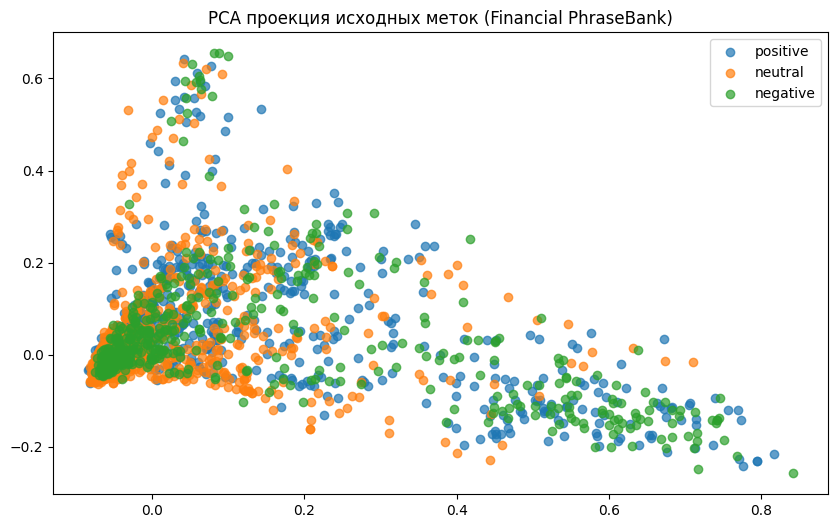

In [44]:
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_vectors.toarray())
print("Explained variance ratio (2 компоненты):", pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
for label in np.unique(true_labels):
    plt.scatter(df_pca[true_labels == label, 0],
                df_pca[true_labels == label, 1],
                label=list(label_map.keys())[label], alpha=0.7)
plt.title("PCA проекция исходных меток (Financial PhraseBank)")
plt.legend()
plt.show()

Метрики для оценки

In [46]:
def evaluate_clustering(X, pred, true, name_dr, name_clust):
    metrics = {
        'Decomposer': name_dr,
        'Clusterization': name_clust,
        'silhouette': silhouette_score(X, pred) if len(np.unique(pred)) > 1 else np.nan,
        'calinski_harabasz': calinski_harabasz_score(X, pred) if len(np.unique(pred)) > 1 else np.nan,
        'davies_bouldin': davies_bouldin_score(X, pred) if len(np.unique(pred)) > 1 else np.nan,
        'ari': adjusted_rand_score(true, pred),
        'ami': adjusted_mutual_info_score(true, pred),
        'homogeneity': homogeneity_completeness_v_measure(true, pred)[0],
        'completeness': homogeneity_completeness_v_measure(true, pred)[1],
        'v_measure': homogeneity_completeness_v_measure(true, pred)[2]
    }
    return metrics

Список DR-методов

In [47]:
dr_methods = {
    'PCA': lambda X: PCA(n_components=2, random_state=42).fit_transform(X.toarray()),
    'UMAP': lambda X: umap.UMAP(n_components=2, random_state=42).fit_transform(X.toarray()),
    't-SNE': lambda X: TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X.toarray()),
    'TriMAP': lambda X: trimap.TRIMAP().fit_transform(X.toarray())
}

## Список алгоритмов кластеризации
clust_methods = {
    'KMeans': lambda X: KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X),
    'AgglomerativeClustering': lambda X: AgglomerativeClustering(n_clusters=3).fit_predict(X),
    'Birch': lambda X: Birch(n_clusters=3).fit_predict(X),
    'DBSCAN': lambda X: DBSCAN(eps=0.5, min_samples=5).fit_predict(X)
}

## Запуск всех пайплайнов
all_metrics = []

for dr_name, dr_func in dr_methods.items():
    print(f"Выполняем {dr_name}...")
    X_dr = dr_func(df_vectors)

    for clust_name, clust_func in clust_methods.items():
        pred = clust_func(X_dr)
        metrics = evaluate_clustering(X_dr, pred, true_labels, dr_name, clust_name)
        all_metrics.append(metrics)

all_metrics_df = pd.DataFrame(all_metrics)
print("\n=== Результаты всех пайплайнов ===")
print(all_metrics_df.sort_values(by='v_measure', ascending=False).head(10))
all_metrics_df.to_csv('metrics_financial_phrasebank.csv', index=False)

Выполняем PCA...
Выполняем UMAP...
Выполняем t-SNE...
Выполняем TriMAP...

=== Результаты всех пайплайнов ===
   Decomposer           Clusterization  silhouette  calinski_harabasz  \
11      t-SNE                   DBSCAN   -0.507336          13.160438   
1         PCA  AgglomerativeClustering    0.764837        8632.788224   
0         PCA                   KMeans    0.774449        9380.516461   
9       t-SNE  AgglomerativeClustering    0.287191        2525.129883   
13     TriMAP  AgglomerativeClustering    0.524990        4360.572266   
7        UMAP                   DBSCAN   -0.047521         249.302322   
8       t-SNE                   KMeans    0.350311        3545.150635   
15     TriMAP                   DBSCAN   -0.338669          20.180113   
4        UMAP                   KMeans    0.382449        3517.095459   
12     TriMAP                   KMeans    0.481231        4917.342773   

    davies_bouldin       ari       ami  homogeneity  completeness  v_measure  
11     

Визуализация

In [50]:
# Сохраняем все DR-проекции для визуализации
dr_projections = {}
for dr_name, dr_func in dr_methods.items():
    dr_projections[dr_name] = dr_func(df_vectors)

In [52]:

fig, axes = plt.subplots(4, 4, figsize=(22, 20))
fig.suptitle('Сравнение всех методов кластеризации на DR представлениях',
             fontsize=18, fontweight='bold')

dr_list = list(dr_methods.keys())
clust_list = list(clust_methods.keys())

for i, dr_name in enumerate(dr_list):
    X_dr = dr_projections[dr_name]
    for j, clust_name in enumerate(clust_list):
        ax = axes[i, j]

        # кластеризация
        if clust_name == 'KMeans':
            pred = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_dr)
        elif clust_name == 'AgglomerativeClustering':
            pred = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_dr)
        elif clust_name == 'Birch':
            pred = Birch(n_clusters=3).fit_predict(X_dr)
        else:
            pred = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_dr)

        scatter = ax.scatter(X_dr[:, 0], X_dr[:, 1],
                             c=pred, cmap='tab10', alpha=0.75, s=12)

        ax.set_title(f"{dr_name} + {clust_name}", fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])


        n_clusters = len(np.unique(pred)) # количество найденных кластеров
        ax.text(0.02, 0.98, f'clusters: {n_clusters}',
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Оценка устойчивочти

In [55]:

def evaluate_stability(dr_projections, clust_methods, n_bootstrap=30, random_state=42):
    """
    Оценивает устойчивость кластеризации с помощью bootstrap.
    Для каждой комбинации DR + Clustering запускает bootstrap и считает средний pairwise ARI.
    """
    print("Запуск оценки устойчивости с помощью bootstrap...\n")

    stability_results = []
    rng = np.random.RandomState(random_state)

    for dr_name, X_dr in dr_projections.items():
        print(f"→ Оценка устойчивости для: {dr_name}")

        for clust_name, clust_func in clust_methods.items():
            all_labels = []

            for i in range(n_bootstrap):
                try:
                    # Bootstrap выборка
                    indices = rng.choice(len(X_dr), size=len(X_dr), replace=True)
                    X_boot = X_dr[indices]

                    # Кластеризация на bootstrap-выборке
                    labels = clust_func(X_boot)
                    all_labels.append(labels)

                except Exception as e:
                    print(f"  Ошибка на итерации {i} для {clust_name}: {e}")
                    continue

            if len(all_labels) < 2:
                print(f"  Недостаточно успешных запусков для {clust_name}")
                mean_ari = np.nan
            else:
                # Вычисляем pairwise ARI между всеми успешными запусками
                pairwise_ari = []
                n_success = len(all_labels)
                for i in range(n_success):
                    for j in range(i + 1, n_success):
                        ari = adjusted_rand_score(all_labels[i], all_labels[j])
                        pairwise_ari.append(ari)

                mean_ari = np.mean(pairwise_ari) if pairwise_ari else np.nan
                std_ari = np.std(pairwise_ari) if pairwise_ari else np.nan

                print(f"    {clust_name:25s} → Mean ARI = {mean_ari:.4f} (±{std_ari:.4f})")

            stability_results.append({
                'Decomposer': dr_name,
                'Clusterization': clust_name,
                'Mean_ARI_stability': round(mean_ari, 4)
            })

    stability_df = pd.DataFrame(stability_results)
    print("\n" + "="*80)
    print("РЕЗУЛЬТАТЫ УСТОЙЧИВОСТИ (отсортировано по убыванию устойчивости):")
    print("="*80)
    print(stability_df.sort_values(by='Mean_ARI_stability', ascending=False))

    return stability_df


stability_df = evaluate_stability(
    dr_projections=dr_projections,
    clust_methods=clust_methods,
    n_bootstrap=30,
    random_state=42
)

Запуск оценки устойчивости с помощью bootstrap...

→ Оценка устойчивости для: PCA
    KMeans                    → Mean ARI = 0.0004 (±0.0117)
    AgglomerativeClustering   → Mean ARI = 0.0005 (±0.0099)
    Birch                     → Mean ARI = 1.0000 (±0.0000)
    DBSCAN                    → Mean ARI = 1.0000 (±0.0000)
→ Оценка устойчивости для: UMAP
    KMeans                    → Mean ARI = 0.0000 (±0.0006)
    AgglomerativeClustering   → Mean ARI = 0.0001 (±0.0028)
    Birch                     → Mean ARI = 0.0000 (±0.0021)
    DBSCAN                    → Mean ARI = -0.0010 (±0.0128)
→ Оценка устойчивости для: t-SNE
    KMeans                    → Mean ARI = 0.0000 (±0.0005)
    AgglomerativeClustering   → Mean ARI = 0.0000 (±0.0018)
    Birch                     → Mean ARI = 0.0000 (±0.0018)
    DBSCAN                    → Mean ARI = 0.0002 (±0.0105)
→ Оценка устойчивости для: TriMAP
    KMeans                    → Mean ARI = -0.0002 (±0.0035)
    AgglomerativeClustering   → Mean 

В результате эксперимента были сравнены 16 комбинаций из 4 методов понижения размерности (PCA, UMAP, t-SNE, TriMAP) и 4 алгоритмов кластеризации (KMeans, AgglomerativeClustering, Birch, DBSCAN)



*   Лучшие результаты показали методы в сочетании с KMeans и AgglomerativeClustering
*   Наиболее высокие показатели V-measure и AMI были у комбинаций PCA + KMeans и PCA + AgglomerativeClustering. Это объясняется тем, что PCA хорошо сохраняет глобальную дисперсию данных, а KMeans и иерархическая кластеризация эффективно работают в пространстве главных компонент
*   t-SNE и TriMAP в целом уступали по внешним метрикам, хотя визуально t-SNE часто давал красивые, хорошо разделимые облака точек

Устойчивость кластеризации:


*   Комбинации PCA + Birch и PCA + DBSCAN, показали Mean ARI ≈ 1. Это связано с тем, что на 2-мерном пространстве PCA большинство алгоритмов (особенно DBSCAN и Birch) при повторных запусках дают практически идентичную разметку. Однако высокая устойчивость здесь часто является «ложной» — алгоритмы просто находят один большой кластер или очень грубое разделение. На визуализации это хорошо видно
*   Все остальные комбинации показали крайне низкую устойчивость, Mean ARI близок к 0. Это означает, что разметка случайна: небольшие изменения в bootstrap-выборке приводят к существенному изменению структуры кластеров
